In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Data A\Practice\Python\cafe_sales\dirty_cafe_sales.csv")
df.head(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [2]:
df.shape

(10000, 8)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


In [4]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [5]:
df.isnull().mean() * 100

Transaction ID       0.00
Item                 3.33
Quantity             1.38
Price Per Unit       1.79
Total Spent          1.73
Payment Method      25.79
Location            32.65
Transaction Date     1.59
dtype: float64

In [6]:
print(df['Item'].unique())
print('---')
print(df['Payment Method'].unique())
print('---')
print(df['Location'].unique()) 

<StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
Length: 11, dtype: str
---
<StringArray>
['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan]
Length: 6, dtype: str
---
<StringArray>
['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR']
Length: 5, dtype: str


In [7]:
import numpy as np

df = df.replace('ERROR', np.nan)
df = df.replace('UNKNOWN', np.nan)

print(df.isnull().sum())

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [ ]:
# CONVERTS STRING COLUMNS INTO NUMERIC
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

#CONVERTS STRING TO DATETIME
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [9]:
# FILL COLUMNS THAT ARE RELATED TO EACH OTHER
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])

In [10]:
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity              38
Price Per Unit        38
Total Spent           40
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [11]:
print(df.groupby('Item')['Price Per Unit'].unique())

Item
Cake        [3.0, nan]
Coffee      [2.0, nan]
Cookie      [1.0, nan]
Juice       [3.0, nan]
Salad       [5.0, nan]
Sandwich    [4.0, nan]
Smoothie    [4.0, nan]
Tea         [1.5, nan]
Name: Price Per Unit, dtype: object


In [12]:
# SET RIGHT VALUES FOR PRICE PER UNIT, REMOVE NAN AS VALUE
correct_prices = {
    'Cake': 3.0,
    'Coffee': 2.0,
    'Cookie': 1.0,
    'Juice': 3.0,
    'Salad': 5.0,
    'Sandwich': 4.0,
    'Smoothie': 4.0,
    'Tea': 1.5
}

df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Item'].map(correct_prices))

df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

df.isnull().sum()

Transaction ID         0
Item                 969
Quantity              38
Price Per Unit         6
Total Spent           41
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [13]:
# SET RIGHT VALUE ON ITEMS BASED ON PRICE PER UNIT
price_to_item = {
    2.0: 'Coffee',
    1.0: 'Cookie',
    5.0: 'Salad',
    1.5: 'Tea'
}
df['Item'] = df['Item'].fillna(df['Price Per Unit'].map(price_to_item))

print(df['Item'].value_counts(dropna=False))
print(df.isnull().sum())

Item
Coffee      1291
Salad       1272
Cookie      1213
Tea         1207
Juice       1171
Cake        1139
Sandwich    1131
Smoothie    1096
NaN          480
Name: count, dtype: int64
Transaction ID         0
Item                 480
Quantity              38
Price Per Unit         6
Total Spent           41
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [14]:
# CALLED EVERY MISSING ROWS IN 'ITEM' THAT HAS A VALUE OF 3.0 & 4.0
mask_3 = (df['Item'].isnull()) & (df['Price Per Unit'] == 3.0)
mask_4 = (df['Item'].isnull()) & (df['Price Per Unit'] == 4.0)

print(f"Missing Values with the Price of 3.0: {mask_3.sum()}")
print(f"Missing Values with the Price of 3.0: {mask_4.sum()}")

Missing Values with the Price of 3.0: 247
Missing Values with the Price of 3.0: 227


In [15]:
idx_3 = df[mask_3].index
for i, idx in enumerate(idx_3):
    df.loc[idx, 'Item'] = 'Cake' if i % 2 == 0 else 'Juice'

idx_4 = df[mask_4].index
for i, idx in enumerate(idx_4):
    df.loc[idx, 'Item'] = 'Sandwich' if i % 2 == 0 else 'Smoothie'

print(df['Item'].value_counts(dropna=False))
print(df.isnull().sum())

Item
Juice       1294
Coffee      1291
Salad       1272
Cake        1263
Sandwich    1245
Cookie      1213
Smoothie    1209
Tea         1207
NaN            6
Name: count, dtype: int64
Transaction ID         0
Item                   6
Quantity              38
Price Per Unit         6
Total Spent           41
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [16]:
# FINAL CLEANING PART
# RERUN COMPUTATION TO CHECK IF MISSING VALUES WILL DECREASE
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])

# MISSING VALUES
df = df.dropna(subset=['Item', 'Transaction Date'])

# FILL MISSING VALUES
df['Payment Method'] = df['Payment Method'].fillna('Unknown')
df['Location'] = df['Location'].fillna('Unknown')

print(df.isnull().sum())

Transaction ID       0
Item                 0
Quantity            33
Price Per Unit       0
Total Spent         33
Payment Method       0
Location             0
Transaction Date     0
dtype: int64


In [17]:
# DROP REMAINING MISSING VALUES
df = df.dropna(subset=['Quantity', 'Total Spent'])

print(df.isnull().sum())

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64


In [18]:
#Report 1 — Sales Overview
total_revenue = df['Total Spent'].sum()
average_transaction = df['Total Spent'].mean().round(2)
total_transaction = df['Total Spent'].count()

print(f"The Total Revenue is: {total_revenue}")
print(f"The Average Transaction is: {average_transaction}")
print(f"Total Number of Transaction: {total_transaction}")

The Total Revenue is: 84779.0
The Average Transaction is: 8.92
Total Number of Transaction: 9501


In [88]:
#Report 2 — Product Performance
print(df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False))
print(df.groupby('Item')['Quantity'].sum().sort_values(ascending=False))
print(df.groupby('Item')['Total Spent'].mean().round(2).sort_values(ascending=False))   

Item
Salad       18215.0
Sandwich    14384.0
Smoothie    14092.0
Juice       11052.0
Cake        10938.0
Coffee       7528.0
Tea          5145.0
Cookie       3425.0
Name: Total Spent, dtype: float64
Item
Coffee      3764.0
Juice       3684.0
Cake        3646.0
Salad       3643.0
Sandwich    3596.0
Smoothie    3523.0
Tea         3430.0
Cookie      3425.0
Name: Quantity, dtype: float64
Item
Salad       15.02
Smoothie    12.23
Sandwich    12.21
Cake         9.17
Juice        8.91
Coffee       6.07
Tea          4.52
Cookie       2.99
Name: Total Spent, dtype: float64


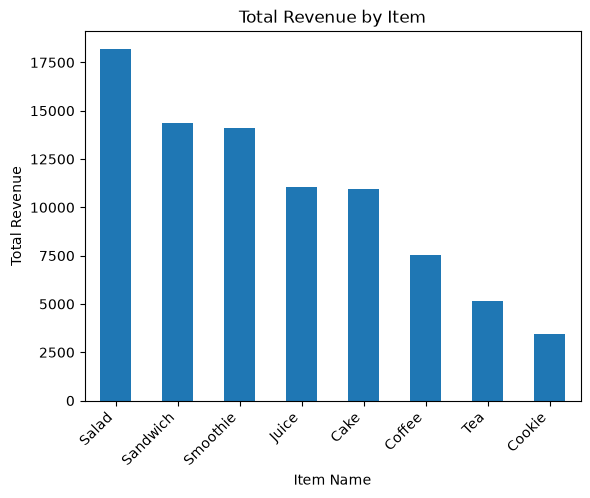

In [20]:
import matplotlib.pyplot as plt

item_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

item_revenue.plot(kind='bar')
plt.title('Total Revenue by Item')
plt.xlabel('Item Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.show()

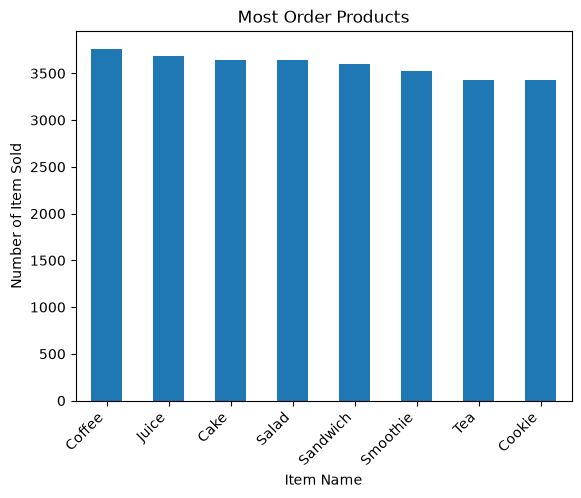

In [89]:
order_count = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False)

order_count.plot(kind='bar')
plt.title('Most Order Products')
plt.xlabel('Item Name')
plt.ylabel('Number of Item Sold')
plt.xticks(rotation=45, ha='right')
plt.show()

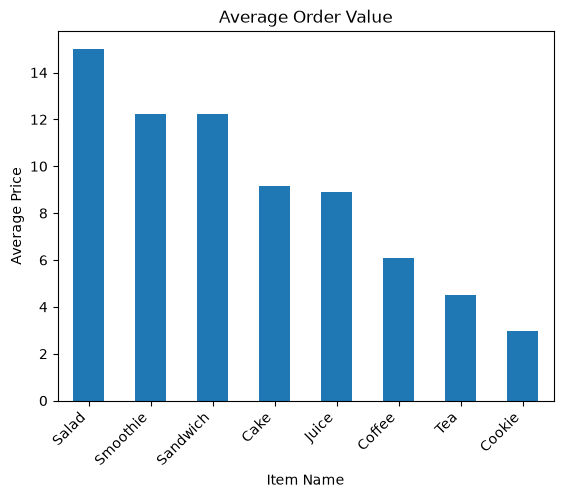

In [22]:
avg_price = df.groupby('Item')['Total Spent'].mean().round(2).sort_values(ascending=False)

avg_price.plot(kind='bar')
plt.title('Average Order Value')
plt.xlabel('Item Name')
plt.ylabel('Average Price')
plt.xticks(rotation=45, ha='right')
plt.show()

In [105]:
#Report 3 — Payment & Location Analysis
print(df.groupby('Payment Method')['Transaction ID'].count().sort_values(ascending=False))
print(df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False))
print(df.groupby('Location')['Total Spent'].mean().round(2).sort_values(ascending=False))

Payment Method
Unknown           3001
Digital Wallet    2189
Credit Card       2160
Cash              2151
Name: Transaction ID, dtype: int64
Location
Unknown     33595.0
In-store    25831.5
Takeaway    25352.5
Name: Total Spent, dtype: float64
Location
In-store    9.04
Unknown     8.93
Takeaway    8.81
Name: Total Spent, dtype: float64


In [103]:
(df['Payment Method'].value_counts(normalize=True) * 100).round(2)

Payment Method
Unknown           31.59
Digital Wallet    23.04
Credit Card       22.73
Cash              22.64
Name: proportion, dtype: float64

In [95]:
(df['Location'].value_counts(normalize=True) * 100).round(2)

Location
Unknown     39.62
Takeaway    30.30
In-store    30.08
Name: proportion, dtype: float64

In [104]:
df['Location'].unique()

<StringArray>
['Takeaway', 'In-store', 'Unknown']
Length: 3, dtype: str

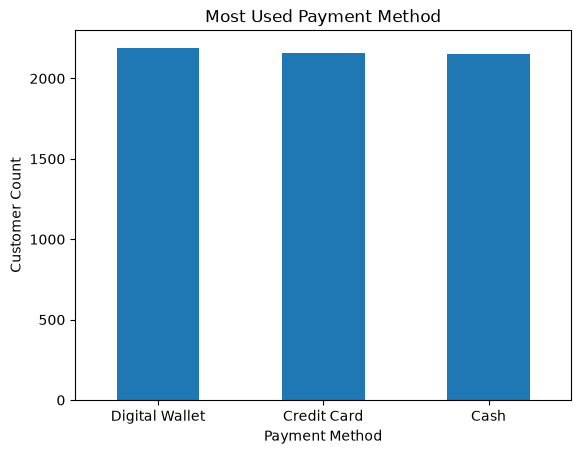

In [25]:
payment_method = df[df['Payment Method'] != 'Unknown'].groupby('Payment Method')['Transaction ID'].count().sort_values(ascending=False)

payment_method.plot(kind='bar')
plt.title('Most Used Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.xticks(rotation=0)
plt.show()

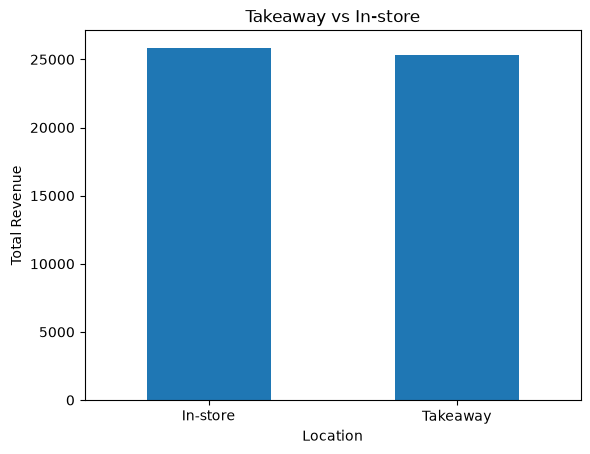

In [106]:
# TOTAL REVENUE BY LOCATION (UNKOWN EXCLUDED)
location_revenue = df[df['Location'] != 'Unknown'].groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

location_revenue.plot(kind='bar')
plt.title('Takeaway vs In-store')
plt.xlabel('Location')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.show()

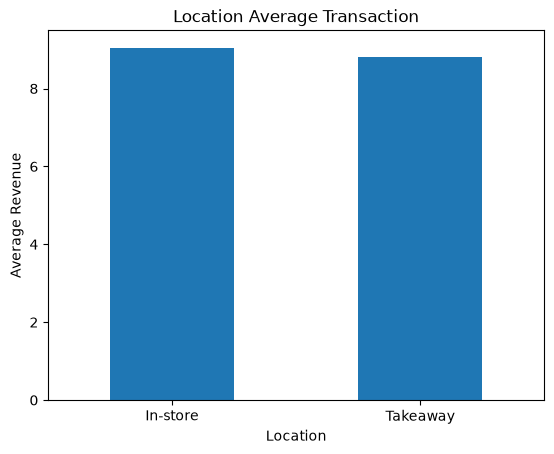

In [27]:
loc_value = df[df['Location'] != 'Unknown'].groupby('Location')['Total Spent'].mean().round(2).sort_values(ascending=False)

loc_value.plot(kind='bar')
plt.title('Location Average Transaction')
plt.xlabel('Location')
plt.ylabel('Average Revenue')
plt.xticks(rotation=0)
plt.show()

In [59]:
#Report 4 — Time Analysis

# Seperate Transaction Date
df['Month'] = df['Transaction Date'].dt.month
df['Month Name'] = df['Transaction Date'].dt.strftime('%B')
df['Day of Week'] = df['Transaction Date'].dt.day_name()
df['Year'] = df['Transaction Date'].dt.year

#Which month has the highest revenue?
df.groupby('Month Name')['Total Spent'].sum().sort_values(ascending=False)

Month Name
June         7353.0
October      7307.0
January      7231.0
March        7192.0
April        7179.0
December     7153.0
August       7084.5
November     6967.0
May          6932.5
July         6876.5
September    6867.0
February     6636.5
Name: Total Spent, dtype: float64

In [70]:
#Which day of the week is busiest?
df.groupby('Day of Week')['Transaction ID'].count().sort_values(ascending=False)

Day of Week
Friday       1381
Monday       1377
Sunday       1377
Thursday     1375
Saturday     1349
Wednesday    1335
Tuesday      1307
Name: Transaction ID, dtype: int64

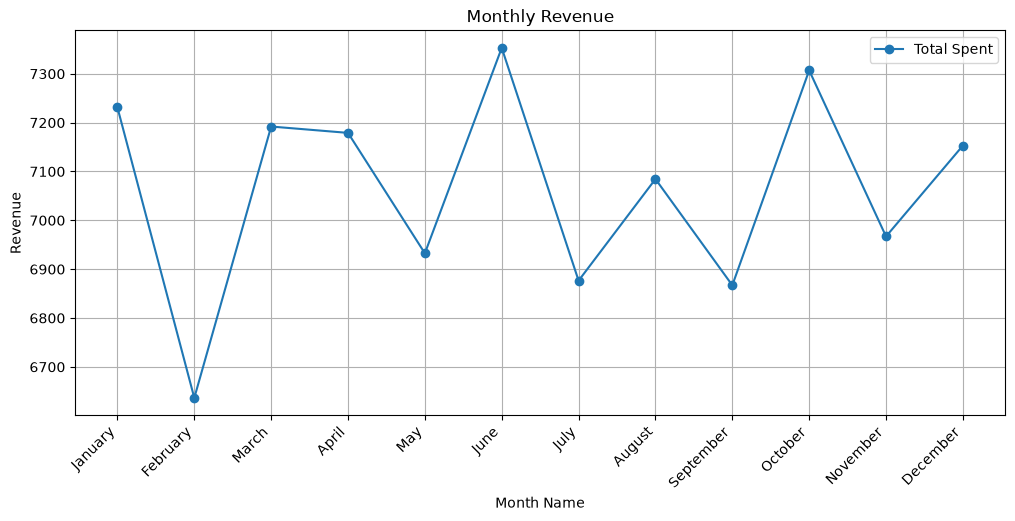

In [ ]:
#Is there a trend in revenue over time?
month_revenue = df.groupby(['Month', 'Month Name'])['Total Spent'].sum().reset_index().sort_values('Month')

month_revenue.plot(x='Month Name', y='Total Spent', kind='line', figsize=(12,5), marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month Name')
plt.ylabel('Revenue')
plt.xticks(range(len(month_revenue)), month_revenue['Month Name'], rotation=45, ha='right')
plt.grid(True)
plt.show()

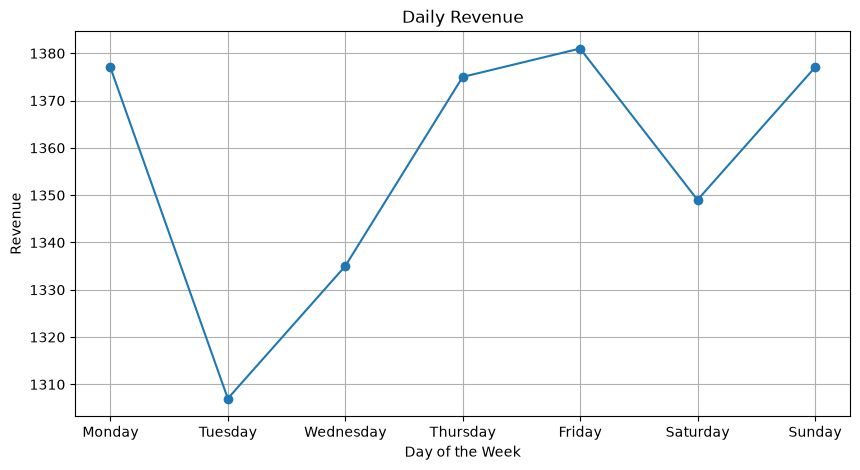

In [74]:
#Is there a trend in revenue over time?
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily_revenue = df.groupby('Day of Week')['Transaction ID'].count()
daily_revenue = daily_revenue.reindex(day_order)

daily_revenue.plot(kind='line', figsize=(10,5), marker='o')
plt.title('Daily Revenue')
plt.xlabel('Day of the Week')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()